In [1]:
#SALES AND DELIVERY DATA ANALYSIS
#The objective of this project is to analyze sales and delivery data to identify business trends, delivery performance, customer behavior, and operational insights using Python data analysis tools.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker
import random

# Initialize Faker(used to generate synthetic data)
fake = Faker()

# Number of rows
num_rows = 1000

# Product categories
categories = [
    "Electronics",
    "Fashion",
    "Groceries",
    "Home Appliances",
    "Books"
]

# Category frequency weights(percentage of category items bought accordingly)
category_weights = [20, 30, 35, 5, 10]

# Cities
cities = [
    "Kochi",
    "Bangalore",
    "Chennai",
    "Mumbai",
    "Delhi"
]

# Order status
statuses = [
    "Delivered",
    "Cancelled"
]

# list to store
data = []

# Generating the dataset
for i in range(num_rows):

    order_date = fake.date_time_between(
        start_date='-6M',
        end_date='now'
    )

    peak_hours = [
        9, 10, 11, 12,
        13, 14, 17, 18,
        19, 20, 21
    ]

    random_hour = random.choice(peak_hours)

    order_date = order_date.replace(
        hour=random_hour,
        minute=random.randint(0, 59),
        second=random.randint(0, 59)
    )

    delivery_days = random.choices(
        [1, 2, 3, 4, 5, 6, 7],
        weights=[5, 10, 25, 30, 20, 7, 3]
    )[0]

    # Delivery date
    delivery_date = (
        pd.to_datetime(order_date)
        + pd.Timedelta(days=delivery_days)
    )

    # Select category with weighted probability of buying
    category = random.choices(
        categories,
        weights=category_weights
    )[0]

    # Category-based pricing
    if category == "Groceries":
        sales_amount = random.randint(100, 1000)

    elif category == "Books":
        sales_amount = random.randint(200, 1500)

    elif category == "Fashion":
        sales_amount = random.randint(500, 4000)

    elif category == "Electronics":
        sales_amount = random.randint(2000, 10000)

    else: #category == Home Appliances
        sales_amount = random.randint(3000, 25000)

    # Rows
    row = {
        "order_id": f"ORD{i+1}",
        "order_date": order_date,
        "delivery_date": delivery_date,
        "category": category,
        "sales_amount": sales_amount,
        "quantity": random.randint(1, 5),
        "status": random.choices(
            statuses,
            weights=[90, 10]
        )[0],
        "city": random.choice(cities)
    }

    # Adding row to dataset
    data.append(row)


df = pd.DataFrame(data)


df.to_csv("sales_delivery_data.csv", index=False)

print("Dataset created successfully!")


print(df.head())

Dataset created successfully!
  order_id          order_date       delivery_date     category  sales_amount  \
0     ORD1 2026-03-02 20:08:28 2026-03-05 20:08:28      Fashion          3057   
1     ORD2 2026-01-21 20:21:48 2026-01-24 20:21:48      Fashion           547   
2     ORD3 2026-03-09 14:25:11 2026-03-13 14:25:11  Electronics          4463   
3     ORD4 2025-12-08 12:27:18 2025-12-10 12:27:18  Electronics          9557   
4     ORD5 2026-05-16 14:49:01 2026-05-19 14:49:01    Groceries           145   

   quantity     status       city  
0         2  Delivered    Chennai  
1         3  Delivered  Bangalore  
2         4  Delivered     Mumbai  
3         4  Delivered      Delhi  
4         5  Delivered      Delhi  


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       1000 non-null   object        
 1   order_date     1000 non-null   datetime64[ns]
 2   delivery_date  1000 non-null   datetime64[ns]
 3   category       1000 non-null   object        
 4   sales_amount   1000 non-null   int64         
 5   quantity       1000 non-null   int64         
 6   status         1000 non-null   object        
 7   city           1000 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 62.6+ KB


In [4]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       1000 non-null   object        
 1   order_date     1000 non-null   datetime64[ns]
 2   delivery_date  1000 non-null   datetime64[ns]
 3   category       1000 non-null   object        
 4   sales_amount   1000 non-null   int64         
 5   quantity       1000 non-null   int64         
 6   status         1000 non-null   object        
 7   city           1000 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 62.6+ KB


In [6]:
df.isnull().sum() #checking for null value

order_id         0
order_date       0
delivery_date    0
category         0
sales_amount     0
quantity         0
status           0
city             0
dtype: int64

In [7]:
df.duplicated().sum()  #checking duplicate value

np.int64(0)

In [8]:
df['delivery_days'] = (  #no.of days between delivery column added
    df['delivery_date']
    - df['order_date']
).dt.days

In [9]:
df.head()

,order_id,order_date,delivery_date,category,sales_amount,quantity,status,city,delivery_days
0,ORD1,2026-03-02 20:08:28,2026-03-05 20:08:28,Fashion,3057,2,Delivered,Chennai,3
1,ORD2,2026-01-21 20:21:48,2026-01-24 20:21:48,Fashion,547,3,Delivered,Bangalore,3
2,ORD3,2026-03-09 14:25:11,2026-03-13 14:25:11,Electronics,4463,4,Delivered,Mumbai,4
3,ORD4,2025-12-08 12:27:18,2025-12-10 12:27:18,Electronics,9557,4,Delivered,Delhi,2
4,ORD5,2026-05-16 14:49:01,2026-05-19 14:49:01,Groceries,145,5,Delivered,Delhi,3


In [10]:
#Analysis Division 
#Top selling category

In [11]:
df.groupby('category')['sales_amount'].sum()

category
Books                86728
Electronics        1105639
Fashion             615820
Groceries           208536
Home Appliances     757838
Name: sales_amount, dtype: int64

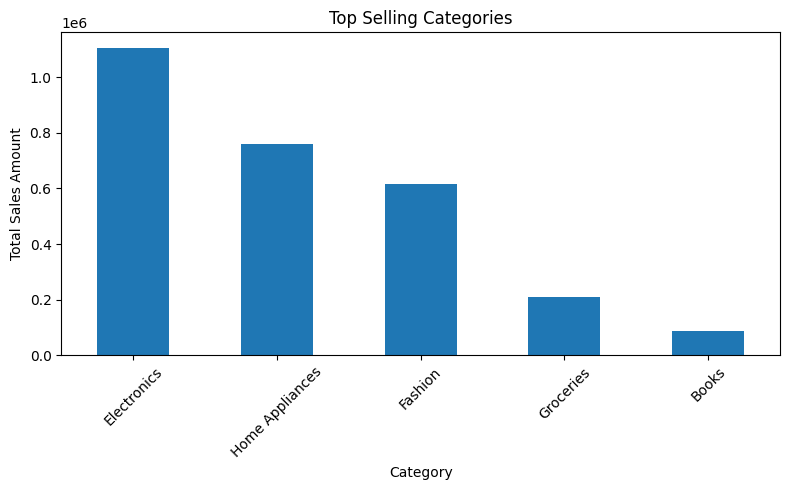

In [12]:
top_categories = df.groupby(
    'category'
)['sales_amount'].sum()

top_categories = top_categories.sort_values(
    ascending=False
)

plt.figure(figsize=(8,5))

top_categories.plot(kind='bar')

plt.title("Top Selling Categories")
plt.xlabel("Category")
plt.ylabel("Total Sales Amount")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [13]:
#Electronics and Home appliances followed by Fashion categories are popular with least popular being books

In [14]:
#Average Delivery timing

In [15]:
average_delivery = df['delivery_days'].mean()

print("Average Delivery Time:", round(average_delivery, 2), "days")

Average Delivery Time: 3.87 days


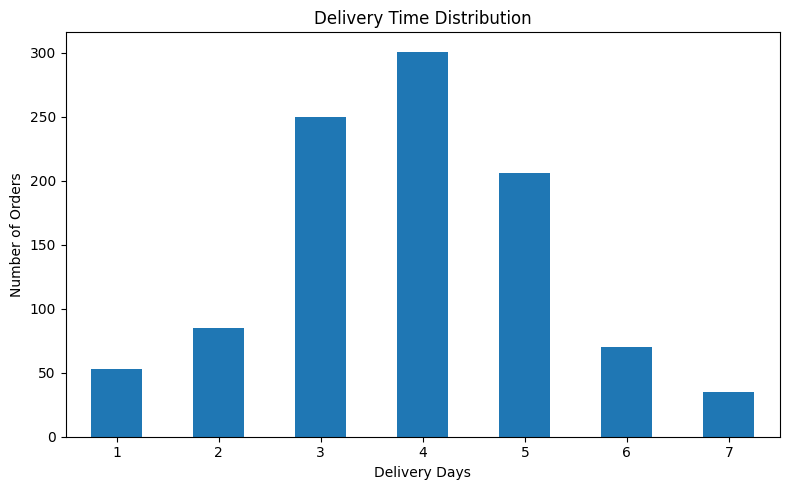

In [16]:
delivery_counts = df['delivery_days'].value_counts().sort_index()

plt.figure(figsize=(8,5))

delivery_counts.plot(
    kind='bar'
)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [17]:
#Most deliveries take place within 3-5 days, very few exceeding 6

In [18]:
#Cancellation percentage

In [19]:
cancelled_orders = df[
    df['status'] == 'Cancelled'
]

cancel_percentage = (
    len(cancelled_orders)
    / len(df)
) * 100

print(
    "Cancellation Percentage:",
    round(cancel_percentage, 2),
    "%"
)

Cancellation Percentage: 9.6 %


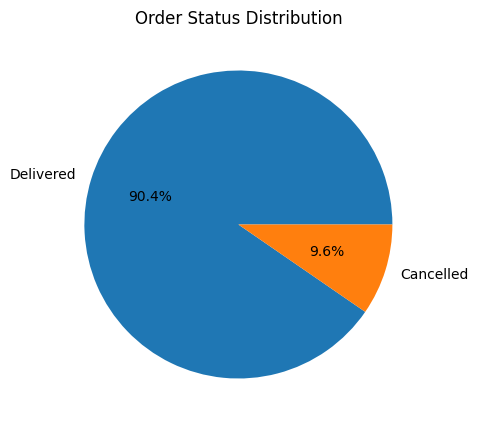

In [20]:
status_counts = df['status'].value_counts()

plt.figure(figsize=(6,5))

status_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Order Status Distribution")
plt.ylabel("")

plt.show()

In [21]:
#Cancellation percentage is comparitively low, smooth operations with slight hinderances

In [22]:
#Peak order timing

In [23]:
df['order_hour'] = df['order_date'].dt.hour

In [24]:
hourly_orders = df['order_hour'].value_counts().sort_index()

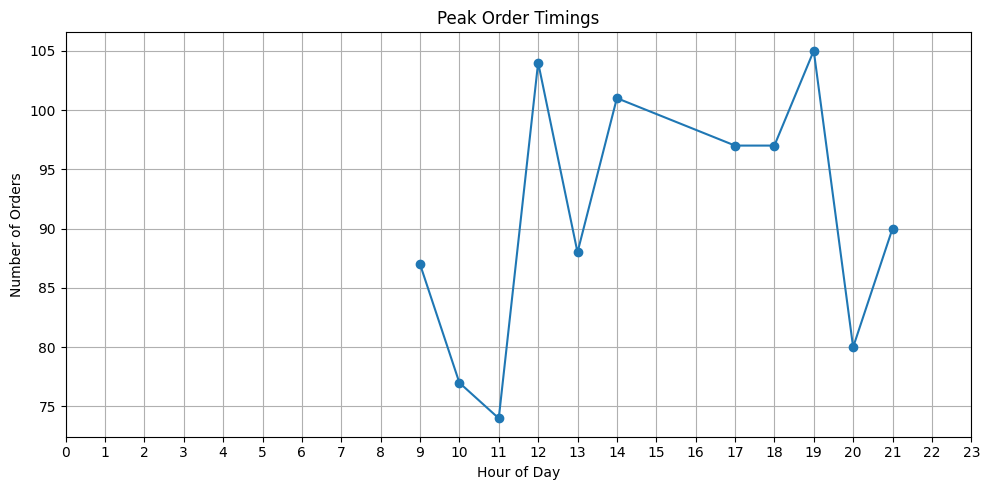

In [25]:
plt.figure(figsize=(10,5))

hourly_orders.plot(
    kind='line',
    marker='o'
)

plt.title("Peak Order Timings")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(0,24))

plt.grid(True)

plt.tight_layout()

plt.show()

In [26]:
#order activity was higher during daytime hours with fluctuations, peak being at 10am

In [27]:
#Monthly sales trend

In [28]:
df['month'] = df['order_date'].dt.strftime('%b') #month name

In [29]:
monthly_sales = df.groupby( #grouping by month
    'month'
)['sales_amount'].sum() 

In [30]:
category_monthly_sales = df.pivot_table(
    values='sales_amount',
    index=df['order_date'].dt.strftime('%b'),
    columns='category',
    aggfunc='mean'
)

In [31]:
month_order = [
    'Jan', 'Feb', 'Mar',
    'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep',
    'Oct', 'Nov', 'Dec'
]

monthly_sales = monthly_sales.reindex(
    month_order
)

monthly_sales = monthly_sales.dropna()

category_monthly_sales = category_monthly_sales.reindex(
    month_order
)

category_monthly_sales = category_monthly_sales.dropna(
    how='all'
)

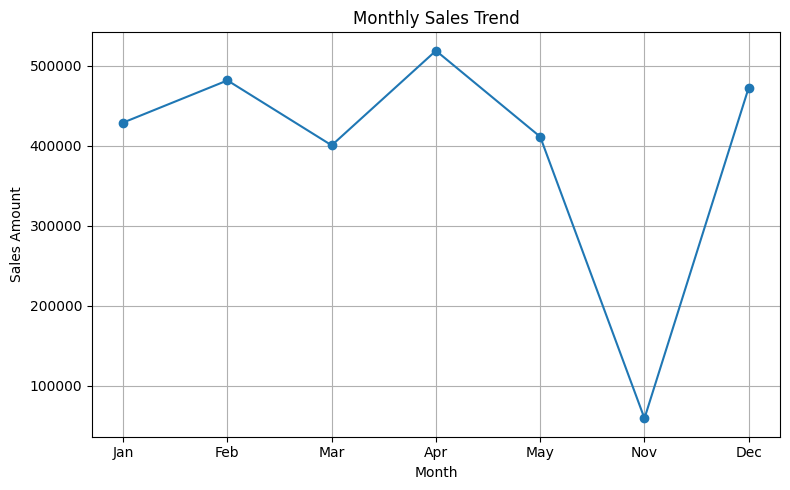

In [32]:
plt.figure(figsize=(8,5))

monthly_sales.plot(
    kind='line',
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")

plt.grid(True)

plt.tight_layout()

plt.show()

In [33]:
#Sales fluctuated across different months due to variation in customer demand and shopping pattern over time

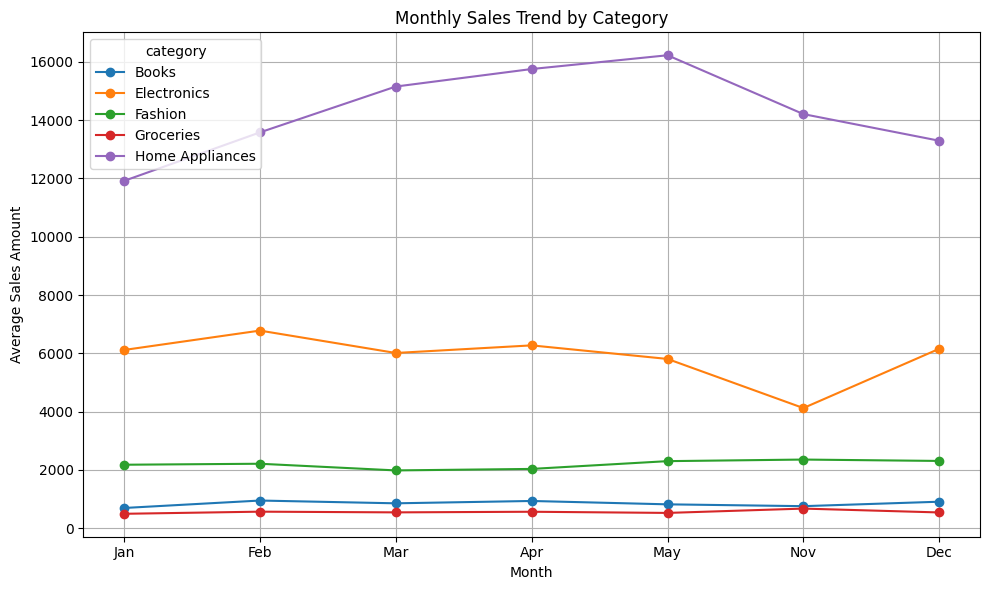

In [34]:
category_monthly_sales.plot(
    figsize=(10,6),
    marker='o'
)

plt.title("Monthly Sales Trend by Category")
plt.xlabel("Month")
plt.ylabel("Average Sales Amount")

plt.grid(True)

plt.tight_layout()

plt.show()

In [35]:
#Delivery Efficiency Suggestions

#1. Improve Delivery Speed
#Most deliveries were completed within 3 to 5 days. Optimizing logistics operations and warehouse coordination can further reduce delivery times and improve customer satisfaction.

#2. Reduce Delivery Delays
#A small number of orders required 6 to 7 days for delivery. Identifying causes of delays and improving route planning can help increase delivery efficiency.

#3. Increase Operational Support During Peak Hours
#Order activity was highest during daytime business hours. Increasing staffing and operational support during peak periods can improve order processing speed.

#4. Improve Inventory Management
#Although the cancellation rate was relatively low, better inventory monitoring and real-time stock updates can help minimize cancelled orders.

#5. Focus on High-Performing Categories
#Electronics and Home Appliances generated the highest revenue. Ensuring faster delivery and sufficient stock availability for these categories can improve customer retention and profitability.

#6. Monitor Monthly Sales Trends
#Tracking monthly sales patterns can help the business prepare for changes in customer demand and improve sales forecasting.

In [36]:
#Delivery Delay

In [37]:
delivered_df = df[
    df['status'] == 'Delivered'
].copy()

In [38]:
delivered_df['delivery_status'] = np.where(
    delivered_df['delivery_days'] >4,
    'Delayed',
    'On Time'
)

In [39]:
delay_counts = delivered_df[
    'delivery_status'
].value_counts()
print(delay_counts)

delivery_status
On Time    623
Delayed    281
Name: count, dtype: int64


In [40]:
delivered_df.head()

,order_id,order_date,delivery_date,category,sales_amount,quantity,status,city,delivery_days,order_hour,month,delivery_status
0,ORD1,2026-03-02 20:08:28,2026-03-05 20:08:28,Fashion,3057,2,Delivered,Chennai,3,20,Mar,On Time
1,ORD2,2026-01-21 20:21:48,2026-01-24 20:21:48,Fashion,547,3,Delivered,Bangalore,3,20,Jan,On Time
2,ORD3,2026-03-09 14:25:11,2026-03-13 14:25:11,Electronics,4463,4,Delivered,Mumbai,4,14,Mar,On Time
3,ORD4,2025-12-08 12:27:18,2025-12-10 12:27:18,Electronics,9557,4,Delivered,Delhi,2,12,Dec,On Time
4,ORD5,2026-05-16 14:49:01,2026-05-19 14:49:01,Groceries,145,5,Delivered,Delhi,3,14,May,On Time


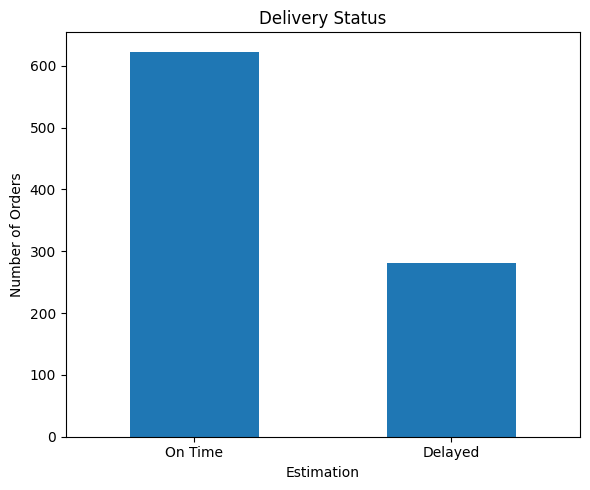

In [41]:
delay_counts.plot(
    kind='bar',
    figsize=(6,5)
)

plt.title("Delivery Status")
plt.xlabel("Estimation")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [42]:
df.to_csv("sales_delivery_data.csv", index=False)

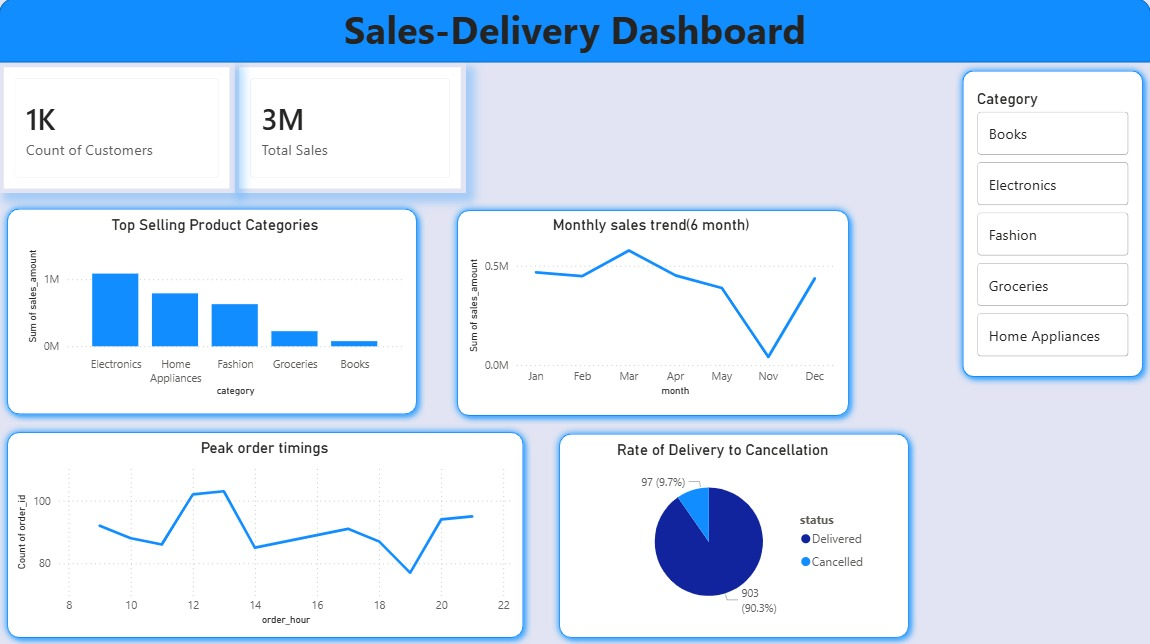

In [43]:
from IPython.display import Image, display

display(Image(filename="Dashboard.jpeg"))